# 📊 GLPI — Visualisation des Données Incidents
**Notebook de préparation avant génération PowerPoint**

Charge `csvjson.json`, applique la logique métier et génère tous les graphiques des 3 slides.

---
**Données :** 243 tickets | 3 mois (Jan–Mars 2026) | Groupes : DC-Cloud-Platform_Team, DC-Unix_Team

## 📦 0. Imports & Configuration

In [8]:
from pathlib import Path
import json, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.titlesize': 13, 'axes.labelsize': 10,
    'figure.facecolor': '#F4F6F8', 'axes.facecolor': '#FFFFFF',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})

BLUE='#1F4E79'; LBLUE='#2E75B6'; LGREEN='#4CAF50'
RED='#C00000'; ORANGE='#E67E22'; GRAY='#7F7F7F'
GROUP_COLORS = {
    'DC-Cloud-Platform_Team': '#2E75B6',
    'DC-Unix_Team': '#E67E22',
    'Non affecté': '#7F7F7F',
}
print('OK')

OK


## 📂 1. Chargement & Préparation

In [10]:
# Inspect source files
csv_source = Path(r'C:\Users\aelazmi2\Downloads\csvjson.json')
json_source = Path(r'C:\Users\aelazmi2\Downloads\Synthèse DC - Incident.json')

print("CSV/JSON SOURCE COLUMNS:")
print("=" * 100)
configs = {}
for source_path, label in [(csv_source, "V1: csvjson.json"), (json_source, "V2: Synthèse DC - Incident.json")]:
    if source_path.exists():
        try:
            df_check = pd.read_json(source_path)
            print(f"\n{label}:")
            print(f"  Shape: {df_check.shape}")
            print(f"  ALL Columns: {list(df_check.columns)}")
            configs[label] = df_check
        except Exception as e:
            print(f"\n{label}: ERROR - {e}")
    else:
        print(f"\n{label}: FILE NOT FOUND")
print("=" * 100)

CSV/JSON SOURCE COLUMNS:

V1: csvjson.json:
  Shape: (243, 26)
  ALL Columns: ['ID', 'Titre', 'Entité', 'Statut', 'Dernière modification', "Date d'ouverture", 'Demandeur - Demandeur', 'Priorité', 'Attribué à - Technicien', 'TTR', 'Attribué à - Groupe de techniciens', 'Date de résolution', 'Temps de résolution dépassé', 'TTR + Progression', 'SLAs - SLAs TTR', 'TTO + progression', 'Type', 'Date de clôture', 'Durée totale', 'Dernière modification par', 'TTO interne dépassé', 'TTR interne dépassé', 'TTO dépassé', 'Suivis - Description', 'Suivis - Rédacteur', '']

V2: Synthèse DC - Incident.json:
  Shape: (29122, 14)
  ALL Columns: ['ID', 'Titre', 'Entité', 'Statut', 'Attribué à - Groupe de techniciens', 'Temps de résolution dépassé', 'Dernière modification par', 'Intervention Admin', "Date d'ouverture", 'Date de résolution', 'time to resolve', 'Server', 'Problem_Category', 'Problem_Sub-Category']


In [11]:
def save_slide1_source(df_current, suffix):
    """Generate Slide 1 - Source and Status breakdown"""
    if len(df_current) == 0:
        print(f'Skipped slide1_source_{suffix}.png - No data')
        return
        
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor('#F4F6F8')
    fig.suptitle('Source des Tickets & Statut de Clôture', fontsize=14, fontweight='bold', color=BLUE)

    # Left pie chart - Source
    ax1 = axes[0]
    if 'Source' in df_current.columns:
        src = df_current['Source'].value_counts()
        cols_pie = [LBLUE if s == 'Automatique' else ORANGE for s in src.index]
        w, t, at = ax1.pie(src.values, labels=src.index, autopct='%1.1f%%', colors=cols_pie,
                         startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
                         pctdistance=0.75, textprops={'fontsize': 11})
        for a in at:
            a.set_fontweight('bold'); a.set_color('white'); a.set_fontsize(12)
    ax1.set_title(f"Source — {df_current['Mois'].max() if 'Mois' in df_current.columns else 'Données'}", fontweight='bold', color=BLUE)

    # Right bar chart - Status
    ax2 = axes[1]
    if 'Statut' in df_current.columns:
        statuts = df_current['Statut'].value_counts()
        scols = {'Clos': LGREEN, 'Résolu': LBLUE, 'En cours (Attribué)': ORANGE, 'Nouveau': GRAY, 'En attente': RED}
        bars2 = ax2.bar(statuts.index, statuts.values, color=[scols.get(s, GRAY) for s in statuts.index], edgecolor='white', width=0.5)
        for b, v in zip(bars2, statuts.values):
            ax2.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.05, str(v), ha='center', fontweight='bold', color=BLUE, fontsize=9)
        ax2.tick_params(axis='x', rotation=15)
    ax2.set_title(f"Statut — {df_current['Mois'].max() if 'Mois' in df_current.columns else 'Données'}", fontweight='bold', color=BLUE)
    ax2.set_ylabel('Tickets')

    plt.tight_layout()
    plt.savefig(f'slide1_source_{suffix}.png', dpi=150, bbox_inches='tight', facecolor='#F4F6F8')
    plt.close()
    print(f'Saved slide1_source_{suffix}.png')

## 🧮 2. Calculs SLA, Backlog, TTR/TTO

In [3]:
print('Metrics are now handled inside process_data() for each source (V1 and V2).')

Metrics are now handled inside process_data() for each source (V1 and V2).


## 📅 3. Slide 1 — Synthèse Mensuelle

In [ ]:
exec(open('process_and_visualize.py', encoding='utf-8').read())

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9d in position 18630: character maps to <undefined>

In [14]:
import glob
import os

print('CLEARING PNG CACHE...')
for f in glob.glob('slide*.png'):
    try:
        os.remove(f)
        print(f'  Deleted: {f}')
    except Exception as e:
        print(f'  Error deleting {f}: {e}')
print('Cache cleared! Ready to regenerate...')


CLEARING PNG CACHE...
Cache cleared! Ready to regenerate...


## 🔴 4. Slide 2 — Jauges SLA & Tableau

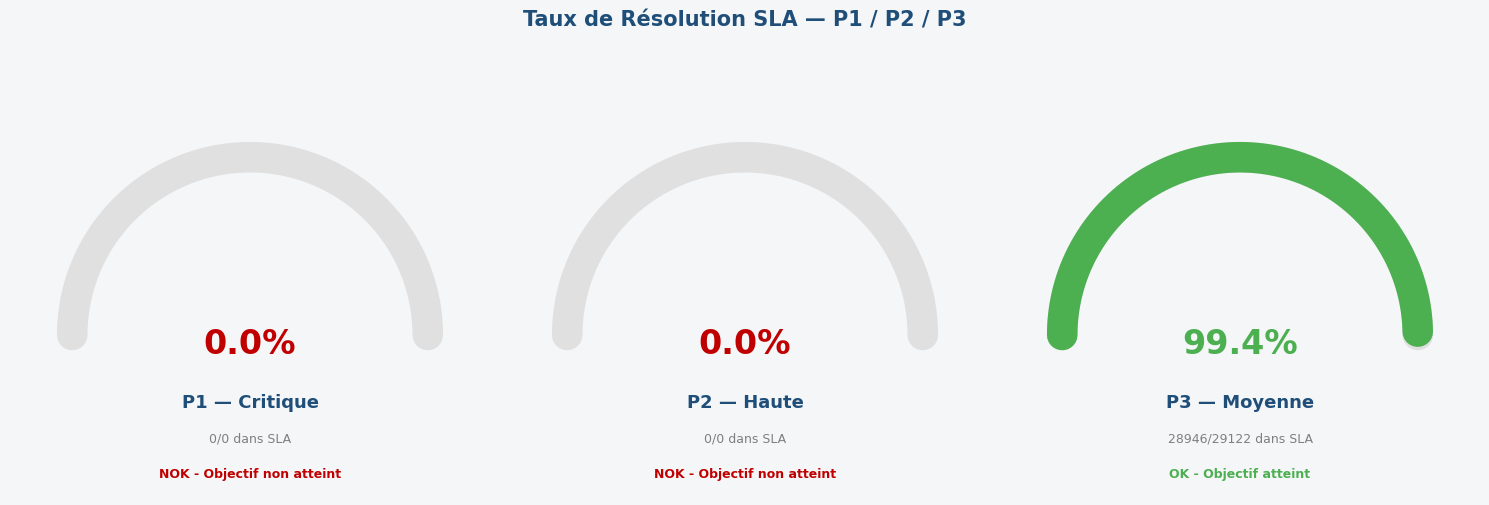

In [ ]:
print('Les jauges SLA sont sauvegardées avec suffixes V1/V2 dans les fichiers PNG.')

Priorite_Code,P1,P2,P3,Total
Groupe,,,,
DC-Cloud-Platform_Team,0,0,25805,25805
DC_DSI_Team,0,0,2891,2891
DC-Unix_Team,0,0,383,383
DC-Database_Team,0,0,24,24
DC-Tooling_Team,0,0,19,19


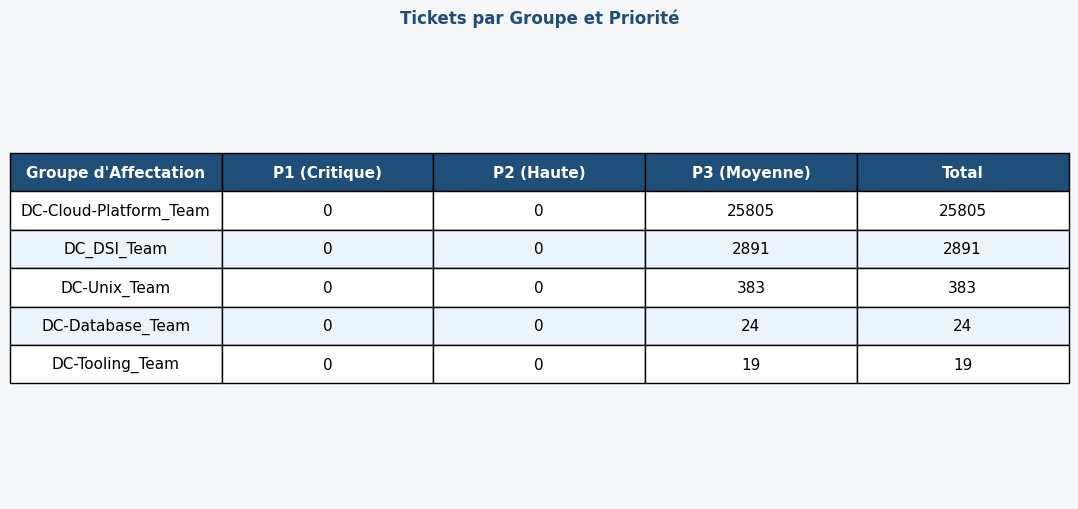

In [ ]:
print('Le tableau par groupe est généré dans process_data() pour chaque source et exporté avec suffixe.')

## 📈 5. Slide 3 — Historique, Backlog, TTR/TTO

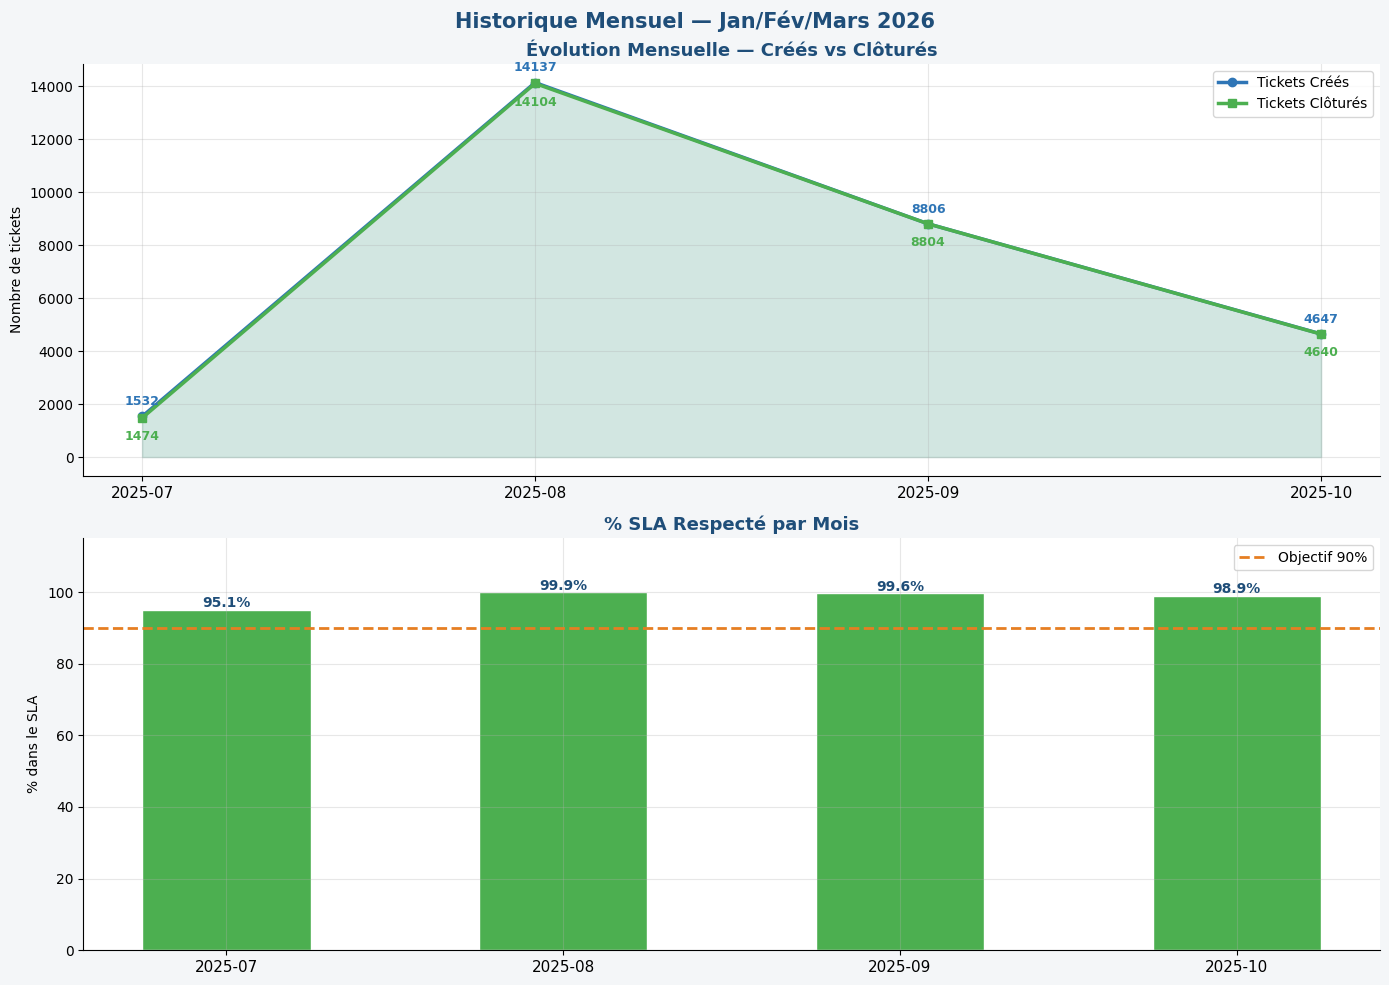

In [ ]:
print('L’historique mensuel et le SLA par mois sont enregistrés dans des fichiers distincts V1/V2.')

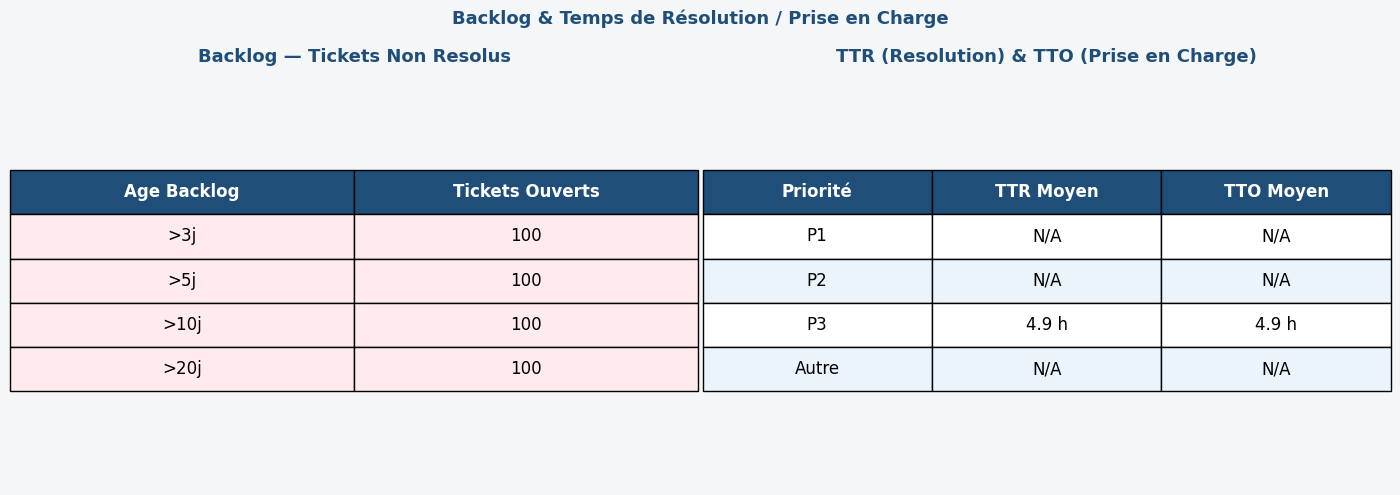

In [ ]:
print('Le backlog et les TTR/TTO ont été sauvegardés dans les PNG suffixées V1 et V2.')

## ✅ 6. Récapitulatif — Fichiers prêts pour PowerPoint

In [ ]:
files = [
    ('slide1_courbe_groupes_V1.png', 'Slide 1 — Courbe + Groupes V1'),
    ('slide1_source_V1.png',         'Slide 1 — Source & Statuts V1'),
    ('slide2_jauges_V1.png',         'Slide 2 — Jauges SLA P1/P2/P3 V1'),
    ('slide2_tableau_V1.png',        'Slide 2 — Tableau par groupe V1'),
    ('slide3_historique_V1.png',     'Slide 3 — Historique + SLA V1'),
    ('slide3_backlog_ttr_V1.png',    'Slide 3 — Backlog + TTR/TTO V1'),
    ('slide1_courbe_groupes_V2.png', 'Slide 1 — Courbe + Groupes V2'),
    ('slide1_source_V2.png',         'Slide 1 — Source & Statuts V2'),
    ('slide2_jauges_V2.png',         'Slide 2 — Jauges SLA P1/P2/P3 V2'),
    ('slide2_tableau_V2.png',        'Slide 2 — Tableau par groupe V2'),
    ('slide3_historique_V2.png',     'Slide 3 — Historique + SLA V2'),
    ('slide3_backlog_ttr_V2.png',    'Slide 3 — Backlog + TTR/TTO V2'),
]
print('FICHIERS PNG POUR POWERPOINT')
print('='*80)
for fname, desc in files:
    ok = os.path.exists(fname)
    size = f'{os.path.getsize(fname)/1024:.0f} KB' if ok else 'MANQUANT'
    print(f'  {"OK" if ok else "XX"}  {fname:35s} {size:8s}  {desc}')
print('='*80)
print('  Lance maintenant : python generate_pptx_from_pngs.py --images-dir C:\\Users\\aelazmi2\\Downloads')

FICHIERS PNG POUR POWERPOINT
  XX  slide1_courbe_groupes.png           MANQUANT  Slide 1 — Courbe + Groupes
  XX  slide1_source.png                   MANQUANT  Slide 1 — Source & Statuts
  XX  slide2_jauges.png                   MANQUANT  Slide 2 — Jauges SLA P1/P2/P3
  XX  slide2_tableau.png                  MANQUANT  Slide 2 — Tableau par groupe
  XX  slide3_historique.png               MANQUANT  Slide 3 — Historique + SLA
  XX  slide3_backlog_ttr.png              MANQUANT  Slide 3 — Backlog + TTR/TTO
  Lance maintenant : python generate_pptx.py
